# 1. Import libaries

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from scipy.spatial import ConvexHull

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, cut_tree

# 2. Rescaling

In [26]:
# Load rfm data
raw_rfm = pd.read_parquet("data/staging/the_complete_journey_rfm_no_outlier.parquet", engine= "pyarrow")
raw_rfm.head()

,household_key,recency,frequency,monetary
0,1,6,86,4330.16
1,3,9,46,2519.75
2,5,9,39,757.07
3,6,5,242,5613.98
4,7,3,59,3350.77


In [27]:
# Clone the RFM values to a new dataframe
rfm_df = raw_rfm[[ 'recency', 'frequency', 'monetary']].copy()

# Instantiate
scaler = StandardScaler()

# Fit_transform
rfm_df_scaled = scaler.fit_transform(rfm_df)
rfm_df_scaled

array([[-0.38288671, -0.05261494,  1.01279346],
       [-0.06642417, -0.71831957,  0.02102064],
       [-0.06642417, -0.83481788, -0.94460489],
       ...,
       [-0.80483676,  1.32872218,  0.02764374],
       [-0.69934924, -0.13582802,  0.25402351],
       [-0.59386173,  0.18038169,  1.08492449]], shape=(1920, 3))

In [28]:
# Convert to dataframe
rfm_df_scaled = pd.DataFrame(rfm_df_scaled)
rfm_df_scaled.columns = ['recency', 'frequency', 'monetary']
rfm_df_scaled.head()

,recency,frequency,monetary
0,-0.382887,-0.052615,1.012793
1,-0.066424,-0.718320,0.021021
2,-0.066424,-0.834818,-0.944605
3,-0.488374,2.543633,1.716091
4,-0.699349,-0.501966,0.476267


# 3. Hierarchical Clustering

In [29]:
sns.set_theme(style="whitegrid")

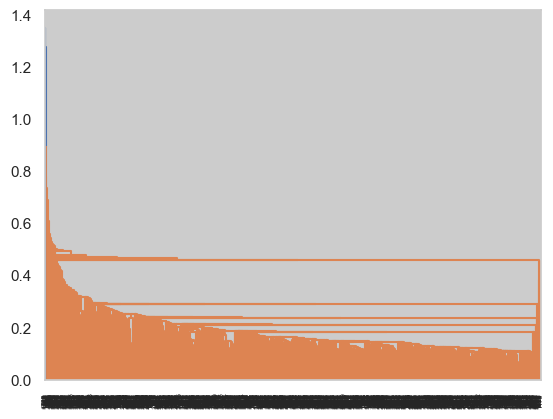

In [30]:
# single linkage
mergings = linkage(rfm_df_scaled, method="single", metric='euclidean')
dendrogram(mergings)
plt.show()

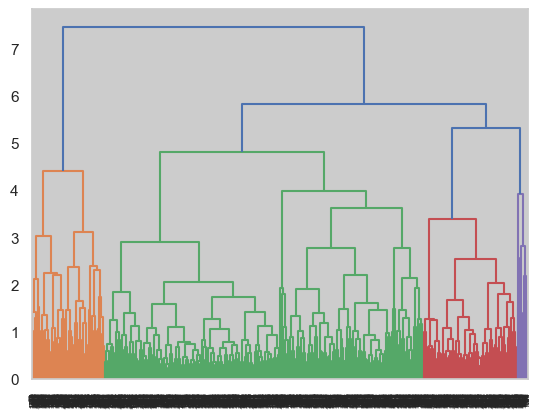

In [31]:
# complete linkage
mergings = linkage(rfm_df_scaled, method="complete", metric='euclidean')
dendrogram(mergings)
plt.show()

> Meaningful cuts using the Dendrogram
- 4 clusters (k = 4) represent the natural grouping suggested by the dendrogram. This is a strong choice because it captures the most significant branches before the clusters begin to split into much smaller sub-groups. However, the green cluster still represents a significant portion of the customer base.

- 5 clusters (k = 5) split the large green cluster into two balanced sub-groups. Because this cluster represents a substantial proportion of the customer base, dividing it provides a more granular view of customer behavior. This finer segmentation can help business teams design more targeted marketing strategies for different customer profiles.

- 6 clusters (k = 6) further divide the smaller orange cluster into two parts, introducing two relatively small but similarly sized groups. However, these additional clusters may not provide substantial extra business insight compared to the simpler segmentation.

- 7, 8, or more clusters only introduce very small sub-groups. Such clusters are not meaningful from either a data perspective or a business perspective, as the segments become too small to justify dedicated marketing strategies.

--> Therefore, hierarchical clustering with 5 or 6 clusters provides a balanced segmentation—small enough to capture meaningful behavioral differences, but not so fragmented that it becomes impractical for business teams to manage.

In [32]:
# Evaluate different numbers of clusters
scores = []

for k in range(3, 11):
    labels = fcluster(mergings, k, criterion='maxclust')
    
    scores.append({
        "k": k,
        "silhouette": silhouette_score(rfm_df_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(rfm_df_scaled, labels),
        "davies_bouldin": davies_bouldin_score(rfm_df_scaled, labels)
    })

scores_df = pd.DataFrame(scores)
print(scores_df)

    k  silhouette  calinski_harabasz  davies_bouldin
0   3    0.320078        1040.551700        0.991092
1   4    0.302242         777.815722        1.004271
2   5    0.274927         915.338982        1.189037
3   6    0.285543         905.888276        1.071743
4   7    0.266253         801.785396        1.065611
5   8    0.258041         710.503523        1.044871
6   9    0.271887         763.728152        1.017317
7  10    0.277830         793.615328        0.988236


> Evaluation using clustering metrics
- k=3 provide the most compact and well-separated groups. But the groups are too broad and may not provide sufficient granuality for business applications.
- Scores of k=6 is not significantly lower than k=4, indicates the groups are not excessive fragmented.
- Scores k=5 also divides the large dominant cluster into more meaningful subgroups while avoiding excessive fragmentation.
- With k>6, the intercall scores are significantly reduced, indicates a not optimal choices.

--> k=5 or k=6 represent a reasonable extension of the segmentation, offering additional behavioral resolution while preserving practical usability for customer analysis and marketing strategy design.

In [33]:
raw_rfm['hier_5_cluster_id'] = cut_tree(mergings, n_clusters=5).reshape(-1, )
raw_rfm['hier_6_cluster_id'] = cut_tree(mergings, n_clusters=6).reshape(-1, )
raw_rfm.head()

,household_key,recency,frequency,monetary,hier_5_cluster_id,hier_6_cluster_id
0,1,6,86,4330.16,0,0
1,3,9,46,2519.75,0,0
2,5,9,39,757.07,0,0
3,6,5,242,5613.98,1,1
4,7,3,59,3350.77,0,0


# 4. Analyze R-F-M of each segments

In [34]:
def plot_rfm_cluster_profiles(
    df,
    recency_col,
    frequency_col,
    monetary_col,
    cluster_col,
    axes=None
):

    summary = (
        df.groupby(cluster_col)[[recency_col, frequency_col, monetary_col]]
        .mean()
        .reset_index()
        .sort_values(cluster_col)
    )

    clusters = summary[cluster_col].astype(str)
    n_clusters = len(summary)

    # Adaptive height
    height = max(3, n_clusters * 0.6)

    if axes is None:
        fig, axes = plt.subplots(1, 3, figsize=(12, height), sharey=True)

    metrics = [recency_col, frequency_col, monetary_col]

    for i, metric in enumerate(metrics):

        bars = axes[i].barh(clusters, summary[metric])

        axes[i].set_xlabel(metric)
        axes[i].grid(axis='x', linestyle='--', alpha=0.4)

        for bar in bars:
            width = bar.get_width()
            axes[i].text(
                width,
                bar.get_y() + bar.get_height()/2,
                f"{width:.2f}",
                va="center",
                ha="left",
                fontsize=8
            )

    axes[0].set_ylabel("Cluster")

    return axes

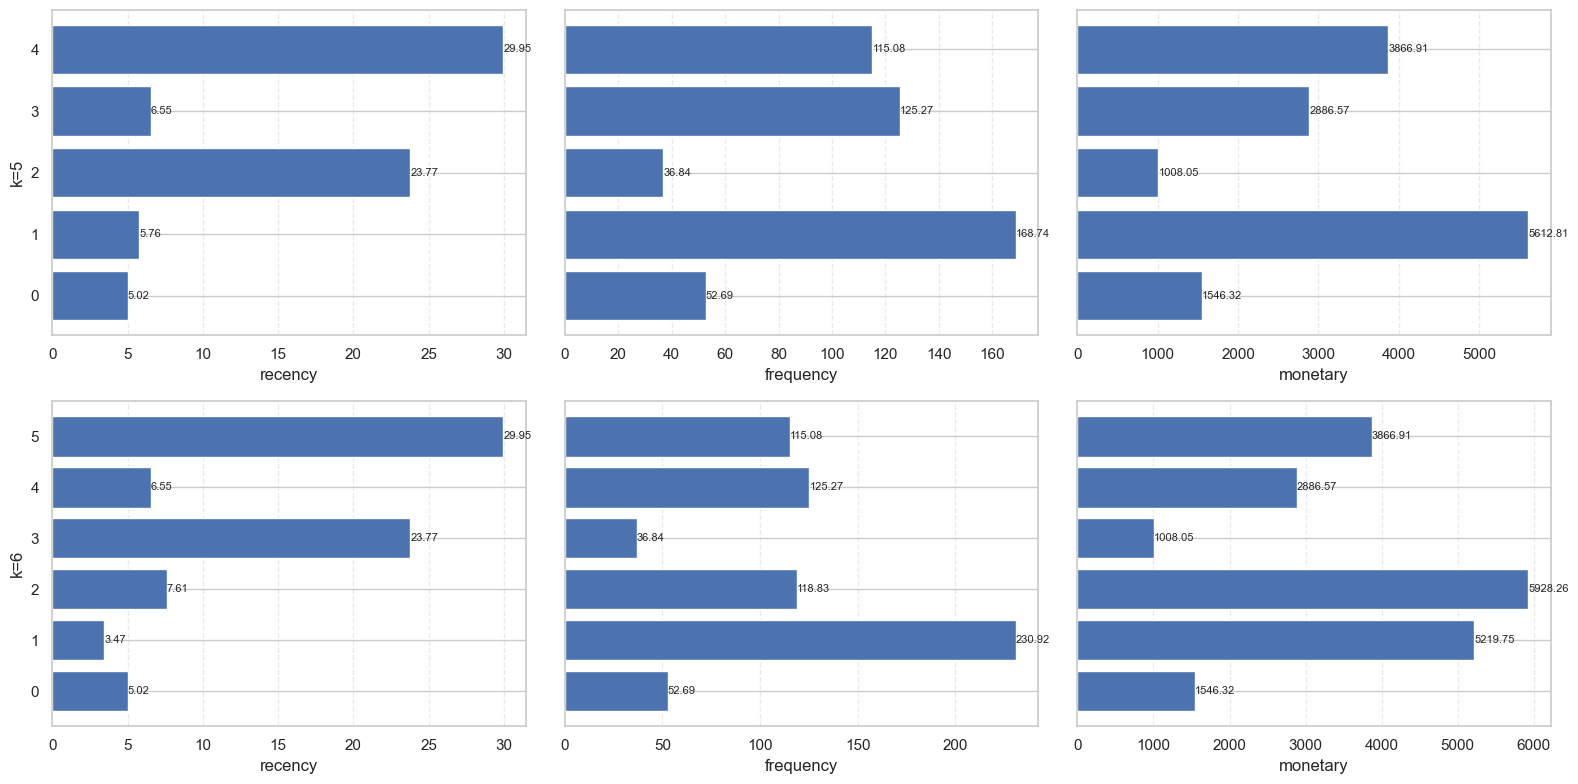

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey='row')

for i, k in enumerate([5,6]):

    plot_rfm_cluster_profiles(
        raw_rfm,
        recency_col="recency",
        frequency_col="frequency",
        monetary_col="monetary",
        cluster_col=f"hier_{k}_cluster_id",
        axes=axes[i]
    )

    axes[i,0].set_ylabel(f"k={k}")

plt.tight_layout()
plt.show()

> Clusters of KMeans k = 5
- `0` : purchase very recent, with low frequency and LTV            --> "New Customers"
- `1` : very recent, with very high frequency and LTV               --> "Champions"
- `2` : purchase very long ago, with low both frequency and LTV     --> "Hibernating"
- `3` : purchase recently, with medium both frequency and LTV          --> "Loyalist"
- `4` : purchase very long ago, with medium frequency and high LTV            --> "At Risk"

> Clusters of KMeans k = 6
- `0` : purchase very recent, with low frequency and LTV            --> "New Customers"
- `1` : very recent, with very high frequency and LTV               --> "Champions"
- `2` : recent, with medium frequency and high LTV                  --> "Loyalist"
- `3` : purchase very long ago, with low both frequency and LTV     --> "Hibernating"
- `4` : purchase recently, with medium both frequency and LTV          --> "Potential Loyalist"
- `5` : purchase very long ago, with medium frequency and high LTV            --> "At Risk"

> Hierarchical clustering produces cleaner behavioral separation, especially in Recency, when compared to KMeans clusters
- Hierarchical clustering produces a clearer separation between the Recency, Frequency, and Monetary (RFM) dimensions, particularly along the recency axis. This stronger separation makes the resulting customer segments easier to interpret. In contrast to some traditional RFM segmentations that include ambiguous categories such as “Need Attention” or “About to Sleep”, the hierarchical clustering results emphasize more clearly defined behavioral groups.

- As a result, the identified segments can be described with more intuitive and actionable labels, such as Champions, At Risk, New Customers, and Hibernating Customers, which better reflect distinct customer behaviors and support more targeted marketing strategies.

In [37]:
# Naming hier_5_cluster_id 
raw_rfm["hier_5_cluster_name"] = raw_rfm["hier_5_cluster_id"].map({
    0: "4. New Customers",
    1: "1. Champions",
    2: "10. Hibernating",
    3: "2. Loyalist",
    4: "9. At Risk"
})

In [38]:
# Naming hier_5_cluster_id 
raw_rfm["hier_6_cluster_name"] = raw_rfm["hier_6_cluster_id"].map({
    0: "4. New Customers",
    1: "1. Champions",
    2: "2. Loyalist",
    3: "10. Hibernating",
    4: "3. Potential Loyalist",
    5: "9. At Risk"
})

# 5. Export the clusters id for later comparison

In [39]:
raw_rfm.head()

,household_key,recency,frequency,monetary,hier_5_cluster_id,hier_6_cluster_id,hier_5_cluster_name,hier_6_cluster_name
0,1,6,86,4330.16,0,0,4. New Customers,4. New Customers
1,3,9,46,2519.75,0,0,4. New Customers,4. New Customers
2,5,9,39,757.07,0,0,4. New Customers,4. New Customers
3,6,5,242,5613.98,1,1,1. Champions,1. Champions
4,7,3,59,3350.77,0,0,4. New Customers,4. New Customers


In [40]:
raw_rfm.to_parquet(
    "data/delivery/rfm_with_hier_clusters.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy"
)